# Question 2: Outreach Prioritization

## Assignment
> Using the selection criteria you made, we have manually picked about 100 sellers at random to check if they were indeed businesses, and for the ones we were unsure of, we gave them a call. It turns out that 83% were business sellers, good job!
>
> It is now March 2025, and the product development for the SMB bundles has completed. We are ready to launch them. The bundles come in two flavors:
>
> - Basic: You will both get you a “Verified seller” icon, a professional seller page, extra pictures for more visibility.
> - Plus: You will get all advantages of Basic, plus extra visibility stickers, and on every ad you get a photo gallery with a link to your other ads.
>
> We have attached a 5% sample of identified prospects. The data consists of monthly usage statistics per category per seller, showing the ads and the features they have used, of the period 2023-2024. In total there are approximately 80k of these prospects in Marktplaats. In our first batch we want to reach out to the 20k sellers that we believe have most potential at this point in time.
>
> To make sure we prioritize the right sellers, we ask you to analyze the data set. We want to call the highest potentials. Provide explorative analyses, and give a recommendation on what type of users to call, and clearly answering why. Any differentiation between which sellers we offer which bundle?
>
> P.S. For this case we only included the SYI sellers, not the Pro sellers, and we excluded cars and jobs ads.


## Exploratory Data Analysis

### Dataset Structure

- **Sample:** 129,501 rows, 3,840 sellers, 24 months, 32 categories.
- **Grain:** one row = seller + month + category.
- **Usage fields:** ad insertions and paid feature counts show behavior.
- **Fee fields:** `FEE_...` columns show actual spend and should drive revenue conclusions.
- **Next step:** aggregate to seller level to rank outreach potential.



In [1]:
import importlib
import functions

functions = importlib.reload(functions)

from functions import (
    Q2_CATEGORY_COLUMN,
    add_q2_row_metrics,
    plot_q2_combined_anomaly_overview,
    plot_q2_fee_concentration,
    plot_q2_fee_mix,
    plot_q2_method_overlap_venn,
    plot_q2_top_categories_by_fees,
    q2_anomaly_detail,
    q2_bundle_recommendation_display,
    q2_data_quality_message,
    q2_metric_summary,
    q2_method_comparison_display,
    q2_monthly_summary,
    q2_overview,
    q2_row_metric_summary,
    q2_selection_summary_display,
    q2_seller_summary_describe,
    q2_spike_comparison,
    read_q2_data,
    score_q2_outreach_readiness,
    seller_level_q2_summary,
    set_plot_style,
    top_categories,
)

set_plot_style()


### Basic Checks

Before scoring sellers, check that the sample is clean at the expected seller-month-category grain.



In [2]:
raw_df = read_q2_data()
df = add_q2_row_metrics(raw_df)
seller_summary = seller_level_q2_summary(df)
monthly_summary = q2_monthly_summary(df)
category_summary = top_categories(df, top_n=df[Q2_CATEGORY_COLUMN].nunique())

q2_overview(raw_df)


{'rows': 129501,
 'columns': 18,
 'unique_sellers': 3840,
 'unique_months': 24,
 'first_month': Timestamp('2023-01-01 00:00:00'),
 'last_month': Timestamp('2024-12-01 00:00:00'),
 'unique_categories': 32}

In [3]:
print(q2_data_quality_message(raw_df))


Data quality check: no missing values, no duplicate seller-month-category rows, and no negative metric values.


In [4]:
q2_metric_summary(raw_df)


,Column,Metric,Total,Non-zero Rows,Non-zero Row %
0,N_FREE_AD_INSERTIONS,Free Ad Insertions,"1,051,612",88923,68.7
1,N_AD_RENEWALS,Ad Renewals,"791,611",65896,50.9
2,FEE_PAID_URL,Paid URL,"€380,885",1706,1.3
3,FEE_AD_RENEWALS,Ad Renewals,"€374,518",17912,13.8
4,N_PAID_AD_INSERTIONS,Paid Ad Insertions,"368,786",8633,6.7
5,FEE_PAID_AD_INSERTIONS,Paid Ad Insertions,"€198,692",8633,6.7
6,FEE_DAGTOPPERS,Dagtoppers,"€167,624",10566,8.2
7,FEE_HOMEPAGE,Homepage,"€87,613",1214,0.9
8,N_PAID_URL,Paid URL,"86,868",5087,3.9
9,N_AD_UPCALLS,Ad Upcalls,"71,537",12977,10.0


In [5]:
q2_row_metric_summary(df)


,Total Ad Insertions,Commercial Uses,Total Fees
count,129501.00,129501.00,"129,501"
mean,10.97,10.69,€9.88
std,283.75,453.98,"€1,041.24"
min,0.00,0.00,€0.00
25%,0.00,0.00,€0.00
50%,1.00,1.00,€0.00
75%,3.00,3.00,€1.07
max,60622.00,121172.00,"€373,856.85"


In [6]:
q2_seller_summary_describe(seller_summary)


,Categories,Total Ad Insertions,Free Ad Insertions,Paid Ad Insertions,Total Feature Uses,Paid Marketplace Actions,Paid Visibility Uses,Total Fees,Active Months,Average Ads per Active Month,Average Fees per Active Month
count,3840.00,3840.00,3840.00,3840.00,3840.00,3840.00,3840.00,"3,840",3840.00,3840.00,"3,840"
mean,6.39,369.90,273.86,96.04,264.58,360.62,58.43,€333.30,12.75,18.63,€17.74
std,5.57,5063.77,1520.17,4831.48,3083.84,7771.67,1176.91,"€6,782.24",8.45,232.53,€310.11
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,€0.00,1.00,0.00,€0.00
25%,2.00,6.00,4.00,0.00,3.00,4.00,1.00,€2.71,5.00,1.22,€0.34
50%,5.00,26.00,21.00,1.00,18.00,22.00,4.00,€24.04,12.00,2.60,€2.59
75%,9.00,108.00,92.00,4.00,82.00,93.00,15.00,€108.18,22.00,7.18,€8.84
90%,15.00,441.20,409.00,15.00,341.10,387.10,61.00,€346.49,24.00,22.64,€23.99
95%,18.00,1012.35,962.20,34.00,800.05,840.15,137.05,€751.56,24.00,47.96,€44.12
99%,23.00,4936.32,4744.03,193.61,3645.20,3892.76,658.21,"€3,579.78",24.00,234.16,€149.16


### Key Visuals

These visuals answer the prioritization questions: who is active, where spend concentrates, which paid products matter, and how concentrated seller value is.



### Spike Check

The November 2023 spike is mostly one seller-category row, not seasonality.

- Seller `65950787` in `Auto-onderdelen (Auto Parts)` explains most of the November spike.
- The row looks real, but it is too extreme to let raw spend drive outreach ranking alone.
- This supports using percentile-based seller scores instead of ranking only by total fees.
- Other anomalies exist, but most are volume spikes with limited fee impact.



In [7]:
q2_anomaly_detail(df, monthly_summary)


,Seller ID,Month,Category,Paid Ad Insertions,Paid URL Features,Paid URL Fees,Total Fees,Share of Monthly Ads,Share of Monthly Fees
0,65950787,2023-11,Auto-onderdelen (Auto Parts),"60,622","60,550","€361,604","€373,857",40.5%,85.4%


In [8]:
spike_comparison, monthly_without_anomaly_seller = q2_spike_comparison(df, monthly_summary)
spike_comparison


,Month,Ads: All Sellers,Ads: Excluding Seller 65950787,Ads Explained by Seller,Ads Explained %,Fees: All Sellers,Fees: Excluding Seller 65950787,Fees Explained by Seller,Fees Explained %
8,2023-09,"49,404","49,404",0,0.0%,"€40,974","€40,940",€35,0.1%
9,2023-10,"52,110","52,110",0,0.0%,"€46,449","€46,397",€52,0.1%
10,2023-11,"149,732","89,110","60,622",40.5%,"€437,987","€64,062","€373,926",85.4%
11,2023-12,"68,023","66,890","1,133",1.7%,"€65,185","€53,428","€11,758",18.0%
12,2024-01,"48,071","45,639","2,432",5.1%,"€39,869","€33,507","€6,362",16.0%


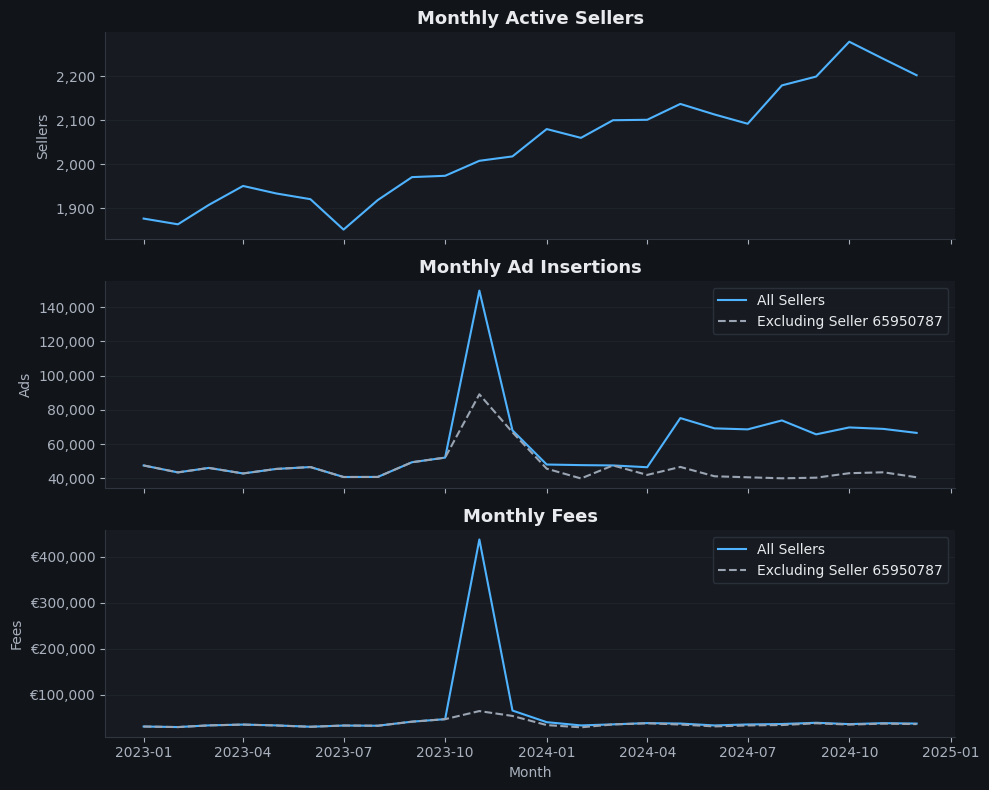

In [9]:
fig, axes = plot_q2_combined_anomaly_overview(monthly_summary, monthly_without_anomaly_seller)


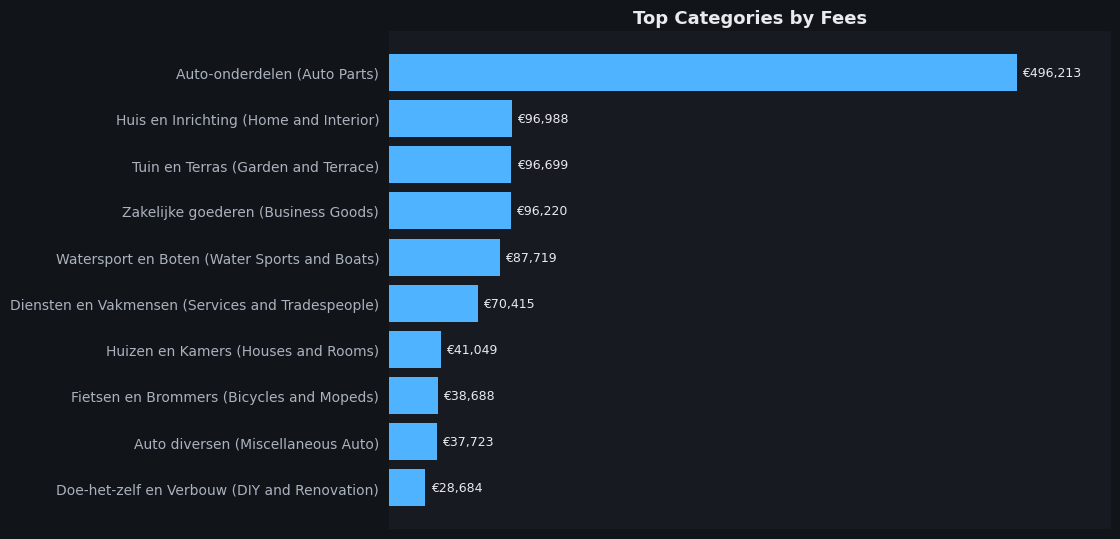

In [10]:
fig, ax = plot_q2_top_categories_by_fees(category_summary)


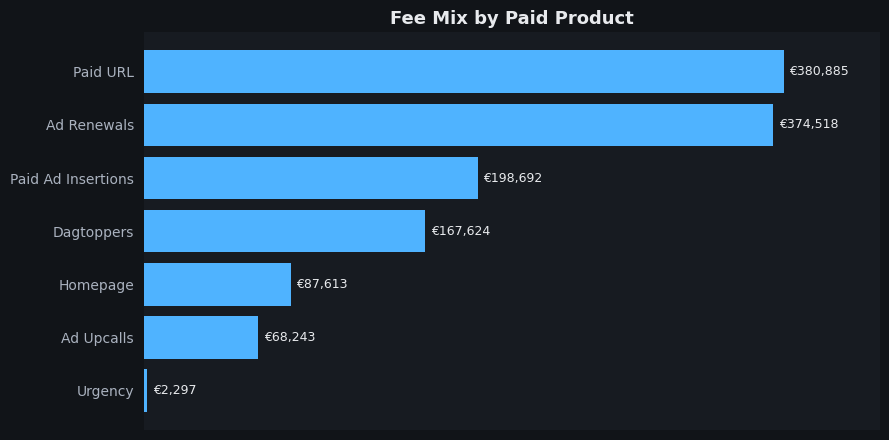

In [11]:
fig, ax = plot_q2_fee_mix(df)


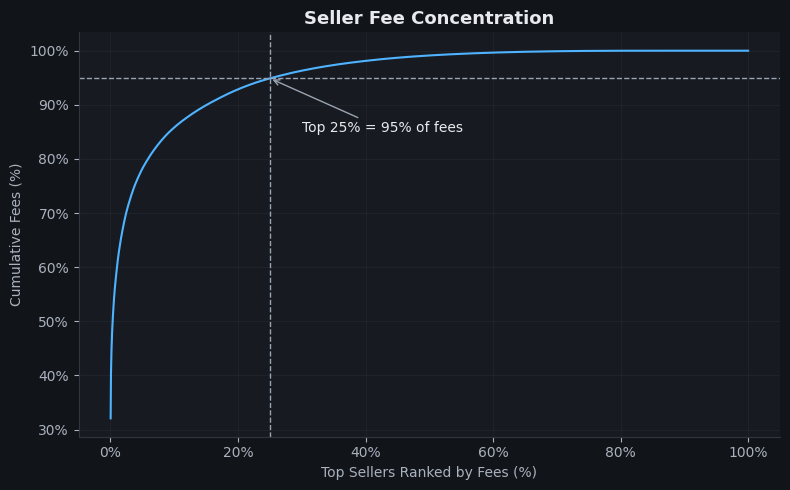

In [12]:
fig, ax = plot_q2_fee_concentration(seller_summary)


### Initial Findings

- The sample is clean: no missing values, duplicate seller-month-category rows, or negative metrics.
- Seller activity is highly skewed: median seller = 26 ads and €24.04 fees; top 1% = thousands of ads and much higher spend.
- Free ad insertions dominate activity; ad renewals and paid insertions are the main paid-usage counts.
- Paid URL, ad renewals, paid insertions, Dagtoppers, and homepage placements drive most fees.
- `Auto-onderdelen` is the largest fee category, even though cars and jobs ads are excluded.



## Outreach Prioritization Method

- **Goal:** rank bundle readiness, not just historical spend.
- **Why:** fee-only ranking misses sellers who are active, growing, broad-category, or already using paid products.
- **Approach:** convert each signal to a seller percentile rank, then average the six scores.

| Signal | Purpose | Definition |
|---|---|---|
| Recent paid usage | Current paid-product need / activity | Paid marketplace actions in the last 6 months |
| Consistency | Reliability as a subscription candidate | Number of months with seller activity across 2023-2024 |
| Category breadth | Fit for professional seller page / bundle value | Number of categories used across 2023-2024 |
| Recent growth | Momentum | Recent paid usage vs prior 6 months, with +1 smoothing |
| Total fees | Historical willingness to pay | Total fees paid across 2023-2024 |
| Paid product breadth | Familiarity with multiple paid products | Number of distinct paid marketplace product types used across 2023-2024 |

Each signal is on a 0-100 percentile scale. Very large raw values improve rank but do not dominate the total score.



The table compares the top 25% selected by readiness score vs the top 25% selected by total fees only. Signal values are average percentile scores for each selected cohort.



In [13]:
scored_sellers = score_q2_outreach_readiness(df, seller_summary)
q2_method_comparison_display(scored_sellers)


,Method,Selected Sellers,Total fees,Avg recent paid usage score,Avg consistency score,Avg category breadth score,Avg recent growth score,Avg total fees score,Avg paid product breadth score,Avg readiness score
0,Readiness score,960,"€1,080,806",82.5,77.4,71.8,59.7,76.6,77.4,74.2
1,Total-fee rank,960,"€1,214,488",71.4,73.9,52.0,45.3,87.5,74.1,67.4


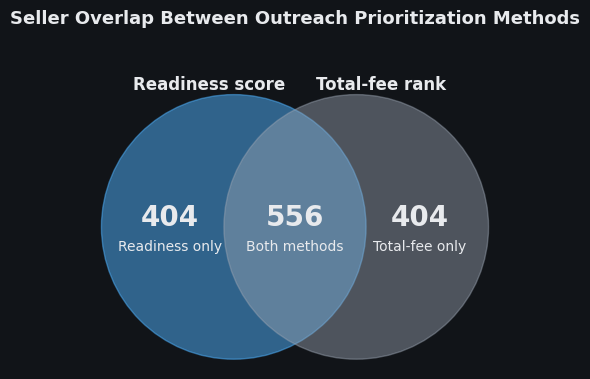

In [14]:
fig, ax = plot_q2_method_overlap_venn(scored_sellers)


In [15]:
q2_selection_summary_display(scored_sellers)


,Selected By,Sellers,Total Fees,Recent Fees,Avg Active Months,Avg Recent Paid Usage,Avg Categories,Avg Paid Product Breadth,Median Growth Ratio
0,Neither,2476,"€44,793","€13,802",8.8,9.2,5.1,2.2,1.0
1,Both methods,556,"€1,060,216","€172,330",21.6,505.8,9.1,4.9,1.1
2,Fee-only,404,"€154,273","€24,512",17.3,19.2,3.5,3.8,0.8
3,Readiness only,404,"€20,591","€8,803",20.0,208.8,13.4,4.2,1.9


Bundle recommendation rule: within the readiness cohort, rank sellers by paid visibility usage, paid product breadth, and category breadth. Top 40% = **Plus**; remaining 60% = **Basic**.



In [16]:
q2_bundle_recommendation_display(scored_sellers)


,Recommended Bundle,Sellers,Total Fees,Avg Total Fees,Avg Recent Paid Usage,Avg Paid Visibility Uses,Avg Categories,Avg Paid Product Breadth
0,Basic,576,"€253,997",€441,159.8,47.6,9.8,4.1
1,Plus,384,"€826,809","€2,153",712.3,431.3,12.6,5.5


### Recommendation

Use the **readiness score** for the first outreach batch.

- It keeps commercial value in the model, but avoids over-indexing on historical spend.
- It adds sellers who are active, consistent, multi-category, growing, and already familiar with paid products.
- These traits are closer to likely outreach response than fee history alone.

Bundle positioning:

- **Plus:** sellers with strong paid visibility usage, multiple paid products, or broad category activity.
- **Basic:** active sellers with lower visibility usage; lead with verified seller and professional page value.



### Next Step: Outcome-Based Ranking

- After initial outreach, supervised learning could replace the manual score.
- Train on response, conversion, and post-signup value.
- Keep the ranking explainable for Sales and leadership.

